# BiTimelyGPT for PhysioNet 2012 Challenge

This Google Colab notebook implements BiTimelyGPT for the PhysioNet 2012 Challenge of predicting in-hospital mortality.

In [ ]:
# import libraries
import os
import torch
import numpy as np
import pandas as pd
from torch import nn, optim
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, auc
import matplotlib.pyplot as plt
import copy


In [ ]:
# mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# BiTimelyGPT to path
import sys
sys.path.append('/content/drive/MyDrive/BiTimelyGPT-main/BiTimelyGPT')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# import BiTimelyGPT modules
from data.data_pipeline import physionet_data_pipeline
from models.BiTimelyGPT import BiTimelyGPT
from layers.heads import PretrainHead, ClfHead
from layers.optimization import get_linear_schedule_with_warmup, AdamW

In [ ]:
# define paths to PhysioNet 2012 data in Google Drive
google_drive_folder = '/content/drive/MyDrive/physionet2012/'
set_a_directory = f"{google_drive_folder}/set-a"
set_b_directory = f"{google_drive_folder}/set-b"
set_c_directory = f"{google_drive_folder}/set-c"

outcomes_a_file = f"{set_a_directory}/Outcomes-a.txt"
outcomes_b_file = f"{set_b_directory}/Outcomes-b.txt"
outcomes_c_file = f"{set_c_directory}/Outcomes-c.txt"

In [ ]:
# define PhysioNet configuration
class PhysioNetConfig:
    def __init__(self):
        # define standard features from PhysioNet
        self.feature_list = [
            'Albumin', 'ALP', 'ALT', 'AST', 'Bilirubin', 'BUN', 'Cholesterol',
            'Creatinine', 'DiasABP', 'FiO2', 'GCS', 'Glucose', 'HCO3', 'HCT',
            'HR', 'K', 'Lactate', 'Mg', 'MAP', 'MechVent', 'Na', 'NIDiasABP',
            'NIMAP', 'NISysABP', 'PaCO2', 'PaO2', 'pH', 'Platelets', 'RespRate',
            'SaO2', 'SysABP', 'Temp', 'TropI', 'TropT', 'Urine', 'WBC', 'Age',
            'Gender', 'Height', 'ICUType', 'Weight'
        ]

        # model parameters
        self.num_layers = 8
        self.num_heads = 4
        self.d_model = 144
        self.qk_dim = 144
        self.v_dim = 288
        self.ffn_proj_size = 576
        self.d_ff = 288
        self.dropout = 0.1
        self.n_output = len(self.feature_list)
        self.n_clf_output = 2


        # Pretraining parameters
        self.pretrain_batch_size = 128
        self.pretrain_learning_rate = 1e-4
        self.pretrain_epochs = 48
        self.pretrain_warmup_steps = 500

        # Fine-tuning parameters
        self.finetune_batch_size = 32
        self.finetune_learning_rate = 2e-4
        self.finetune_epochs = 96
        self.finetune_warmup_steps = 1000
        self.gradient_clip = 1.0

        # BiTimelyGPT specific
        self.use_bias_in_msr = False
        self.use_bias_in_mlp = True
        self.use_bias_in_msr_out = False
        self.use_default_gamma = False
        self.forward_impl = 'parallel'
        self.chunk_size = 12
        self.seq_len = 2880  # 48 hours * 60 minutes
        self.chunk_size = 60  # process in 1-hour chunks
        self.activation = 'gelu'
        self.head_type = 'clf'  # using (binary) classification head

        # GPU and optimization settings
        self.use_gpu = torch.cuda.is_available()
        self.use_grad_ckp = True
        self.use_grad_accum = True
        self.accum_steps = 2
        self.use_amp = False
        self.use_multi_gpu = False
        self.devices = '0'

        self.output_retentions = False

# init config
config = PhysioNetConfig()


In [ ]:
# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# random seeds
torch.manual_seed(42)
np.random.seed(42)

# init base model structure (head will be set later)
model = BiTimelyGPT(configs=config, head_type='pretrain').to(device)
print("Initial model created with Pretrain head.")


Initial model created with Pretrain head.


In [ ]:
# load training data
config.batch_size = config.pretrain_batch_size
train_data_path = set_a_directory
train_outcomes_path = outcomes_a_file
train_dataset, train_loader = physionet_data_pipeline(
    train_data_path,
    train_outcomes_path,
    config,
    split='train'
)

# load validation data
config.batch_size = config.finetune_batch_size
val_data_path = set_b_directory
val_outcomes_path = outcomes_b_file
val_dataset, val_loader = physionet_data_pipeline(
    val_data_path,
    val_outcomes_path,
    config,
    split='val'
)

# load test data (set-c) for final metrics
test_data_path = set_c_directory
test_outcomes_path = outcomes_c_file
test_dataset, test_loader = physionet_data_pipeline(
    test_data_path,
    test_outcomes_path,
    config,
    split='test'
)



In [ ]:
# define optimizer, scheduler
print("--- starting pretraining phase ---")

pretrain_optimizer = AdamW(
    model.parameters(),
    lr=config.pretrain_learning_rate,
    weight_decay=0.01
)

# calculate total steps
num_pretraining_steps = len(train_loader) * config.pretrain_epochs
pretrain_scheduler = get_linear_schedule_with_warmup(
   pretrain_optimizer,
   config.pretrain_warmup_steps,
   num_pretraining_steps
)

# early-stopping hyper-params
patience   = 5
min_delta  = 0.02
best_loss  = float('inf')
epochs_no_improve = 0

# pretraining loss
pretrain_criterion = nn.MSELoss() # used in model.compute_pretrain_loss


# pretraining loop
for epoch in range(config.pretrain_epochs):
    model.train()
    pretrain_losses = []

    for i, batch_data in enumerate(train_loader):
        batch_x, _, attention_mask = [b.to(device) for b in batch_data] # ignore labels during pretrain

        if i % config.accum_steps == 0:
            pretrain_optimizer.zero_grad()

        # forward pass for pretraining
        loss = model(batch_x, y=None,
                     retention_mask=None,
                     forward_impl=config.forward_impl,
                     chunk_size=config.chunk_size)

        if torch.isnan(loss):
             print(f"warning: nan loss encountered at pretrain epoch {epoch+1}, batch {i}. skipping batch.")
             pretrain_optimizer.zero_grad()
             continue

        # scale loss and backprop
        scaled_loss = loss / config.accum_steps
        scaled_loss.backward()

        # gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), config.gradient_clip)

        # update weights
        if (i + 1) % config.accum_steps == 0 or (i + 1) == len(train_loader):
            pretrain_optimizer.step()
            pretrain_scheduler.step()

        pretrain_losses.append(loss.item())

    avg_pretrain_loss = np.mean(pretrain_losses)
    print(f'pretrain epoch {epoch+1}/{config.pretrain_epochs} -- avg loss: {avg_pretrain_loss:.4f}')

    # early-stopping logic
    if avg_pretrain_loss < best_loss * (1 - min_delta):
        best_loss = avg_pretrain_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_pretrain.pt")   # checkpoint
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"early stopping triggered at epoch {epoch+1}. "
                  f"best pre-train loss = {best_loss:.4f}")
            break
print("--- pretraining phase complete ---")

--- Starting Pretraining Phase ---


/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Pretrain Epoch 1/48 -- Avg Loss: 71.2771
Pretrain Epoch 2/48 -- Avg Loss: 70.9904
Pretrain Epoch 3/48 -- Avg Loss: 69.9825
Pretrain Epoch 4/48 -- Avg Loss: 67.5676
Pretrain Epoch 5/48 -- Avg Loss: 64.4703
Pretrain Epoch 6/48 -- Avg Loss: 59.9116
Pretrain Epoch 7/48 -- Avg Loss: 55.8649
Pretrain Epoch 8/48 -- Avg Loss: 50.5019
Pretrain Epoch 9/48 -- Avg Loss: 46.3577
Pretrain Epoch 10/48 -- Avg Loss: 44.3348
Pretrain Epoch 11/48 -- Avg Loss: 42.1638
Pretrain Epoch 12/48 -- Avg Loss: 40.9703
Pretrain Epoch 13/48 -- Avg Loss: 40.9525
Pretrain Epoch 14/48 -- Avg Loss: 39.8047
Pretrain Epoch 15/48 -- Avg Loss: 39.4914
Pretrain Epoch 16/48 -- Avg Loss: 40.3852
Pretrain Epoch 17/48 -- Avg Loss: 40.9605
Pretrain Epoch 18/48 -- Avg Loss: 41.4323
Pretrain Epoch 19/48 -- Avg Loss: 42.0598
Early stopping triggered at epoch 19. Best pre-train loss = 39.8047
--- Pretraining Phase Complete ---


In [ ]:
# switch to fine-tuning
print("--- Switching to Fine-tuning Phase ---")
# keep the pretrained weights, but replace the head
model.head = ClfHead(config.d_model, config.n_clf_output).to(device)
model.head_type = 'clf' # update the model's internal state
print(f"Model head switched to ClfHead for fine-tuning with {config.n_clf_output} outputs.")

# define fine-tuning optimizer, scheduler
optimizer = AdamW(
   model.parameters(),
   lr=config.finetune_learning_rate,
   weight_decay=0.01
)

# fine-tuning scheduler setup
num_finetune_steps = len(train_loader) * config.finetune_epochs
scheduler = get_linear_schedule_with_warmup(
   optimizer,
   config.finetune_warmup_steps,
   num_finetune_steps
)

# fine-tuning loss function
criterion = nn.CrossEntropyLoss()

In [ ]:
# save paths for best model
best_model_path = os.path.join("best_model_bitimelygpt.pt")

criterion = nn.CrossEntropyLoss()  # loss function

# We will track the best AUC over epochs
best_val_auc = 0.0

print("--- Starting Fine-tuning Training Loop ---")
for epoch in range(config.finetune_epochs):
    # training phase (fine-tuning)
    model.train()
    train_losses = []

    for i, batch_data in enumerate(train_loader):
        # unpack batch data including attention mask
        batch_x, batch_y, attention_mask = [b.to(device) for b in batch_data]

        if i % config.accum_steps == 0:
            optimizer.zero_grad()

        # forward pass for classification
        assert model.head_type == 'clf', "Model head_type should be 'clf' for fine-tuning"

        hidden_states = model.conv_subsampling(batch_x)[0]
        hidden_states = model.input_projection(hidden_states)

        # handle attention_mask subsampling
        if attention_mask.shape[1] > hidden_states.shape[1]:
            attention_mask = attention_mask[:, ::4]
            attention_mask = attention_mask[:, :hidden_states.shape[1]]

        # pass through retention blocks
        for l, block in enumerate(model.blocks):
            block_outputs = block(
                hidden_states,
                retention_mask=attention_mask,
                forward_impl=config.forward_impl,
                chunk_size=config.chunk_size
            )
            hidden_states = block_outputs[0]
            if (l + 1) == model.n_layers:
                hidden_states_PTP = hidden_states

        # classification head
        X = model.ln_f(hidden_states_PTP)  # final LayerNorm
        logits = model.head(X)             # ClfHead (mean-pool + linear)

        # calculate classification loss
        raw_loss = criterion(logits, batch_y)

        # scale loss and backpropagate
        scaled_loss = raw_loss / config.accum_steps
        scaled_loss.backward()

        # gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), config.gradient_clip)

        # update weights
        if (i + 1) % config.accum_steps == 0 or (i + 1) == len(train_loader):
            optimizer.step()
            scheduler.step()

        train_losses.append(raw_loss.item())

    avg_train_loss = np.mean(train_losses)
    print(f'Fine-tune Epoch {epoch+1}/{config.finetune_epochs} -- Train Loss: {avg_train_loss:.4f}')

    # validation phase (fine-tuning)
    model.eval()
    val_losses = []

    # collect predicted probabilities & labels for AUC
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for i, batch_data in enumerate(val_loader):
            batch_x, batch_y, attention_mask = [b.to(device) for b in batch_data]

            hidden_states = model.conv_subsampling(batch_x)[0]
            hidden_states = model.input_projection(hidden_states)

            if attention_mask.shape[1] > hidden_states.shape[1]:
                attention_mask = attention_mask[:, ::4]
                attention_mask = attention_mask[:, :hidden_states.shape[1]]

            for l, block in enumerate(model.blocks):
                block_outputs = block(
                    hidden_states,
                    retention_mask=attention_mask,
                    forward_impl=config.forward_impl,
                    chunk_size=config.chunk_size
                )
                hidden_states = block_outputs[0]
                if (l + 1) == model.n_layers:
                    hidden_states_PTP = hidden_states

            X_val = model.ln_f(hidden_states_PTP)
            logits_val = model.head(X_val)

            loss_val = criterion(logits_val, batch_y)
            val_losses.append(loss_val.item())

            # probability of class=1 for AUC
            probs_val = torch.softmax(logits_val, dim=1)[:, 1]
            all_probs.extend(probs_val.detach().cpu().tolist())
            all_labels.extend(batch_y.detach().cpu().tolist())

    avg_val_loss = np.mean(val_losses)
    print(f'Fine-tune Epoch {epoch+1}/{config.finetune_epochs} -- Validation Loss: {avg_val_loss:.4f}')

    # calculate AUC (skip if only one class in the batch)
    if len(np.unique(all_labels)) > 1:
        fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
        roc_auc_val = auc(fpr, tpr)
        print(f"Validation AUC: {roc_auc_val:.4f}")
    else:
        print("Validation AUC calculation skipped: Only one class present in this validation set.")
        roc_auc_val = 0.0

    # save best model by validation AUC
    if epoch >= 0 and roc_auc_val > best_val_auc:
        best_val_auc = roc_auc_val
        best_val_metrics = {
            'auc': best_val_auc,
            'loss': avg_val_loss
        }
        torch.save({
            'model_state_dict': model.state_dict(),
            'config': config,
            'metrics': best_val_metrics
        }, best_model_path)
        print(f"==> Best fine-tuned model saved to {best_model_path} (AUC: {roc_auc_val:.4f})")

--- Starting Fine-tuning Training Loop ---
Fine-tune Epoch 1/96 -- Train Loss: 1.1506
Fine-tune Epoch 1/96 -- Validation Loss: 0.9799
Validation AUC: 0.5600
==> Best fine-tuned model saved to best_model_bitimelygpt.pt (AUC: 0.5600)
Fine-tune Epoch 2/96 -- Train Loss: 0.9220
Fine-tune Epoch 2/96 -- Validation Loss: 0.6328
Validation AUC: 0.5928
==> Best fine-tuned model saved to best_model_bitimelygpt.pt (AUC: 0.5928)
Fine-tune Epoch 3/96 -- Train Loss: 0.5591
Fine-tune Epoch 3/96 -- Validation Loss: 0.4442
Validation AUC: 0.5970
==> Best fine-tuned model saved to best_model_bitimelygpt.pt (AUC: 0.5970)
Fine-tune Epoch 4/96 -- Train Loss: 0.4215
Fine-tune Epoch 4/96 -- Validation Loss: 0.4210
Validation AUC: 0.5876
Fine-tune Epoch 5/96 -- Train Loss: 0.4097
Fine-tune Epoch 5/96 -- Validation Loss: 0.4134
Validation AUC: 0.5982
==> Best fine-tuned model saved to best_model_bitimelygpt.pt (AUC: 0.5982)
Fine-tune Epoch 6/96 -- Train Loss: 0.4033
Fine-tune Epoch 6/96 -- Validation Loss: 0.4

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.calibration import calibration_curve

# load best model
best_model_path = os.path.join("best_model_bitimelygpt.pt")

checkpoint = torch.load(best_model_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print("Best model loaded from:", best_model_path)

# collect predictions on set-c (test_loader)
all_probs_test = []
all_labels_test = []

with torch.no_grad():
    for batch_data in test_loader:
        batch_x, batch_y, attention_mask = [b.to(device) for b in batch_data]

        # forward pass
        hidden_states = model.conv_subsampling(batch_x)[0]
        hidden_states = model.input_projection(hidden_states)

        # adjust attention mask
        if attention_mask.shape[1] > hidden_states.shape[1]:
            attention_mask = attention_mask[:, ::4]
            attention_mask = attention_mask[:, :hidden_states.shape[1]]

        for l, block in enumerate(model.blocks):
            block_outputs = block(
                hidden_states,
                retention_mask=attention_mask,
                forward_impl=config.forward_impl,
                chunk_size=config.chunk_size
            )
            hidden_states = block_outputs[0]
            if (l + 1) == model.n_layers:
                hidden_states_PTP = hidden_states

        X_test = model.ln_f(hidden_states_PTP) # apply final LN
        logits_test = model.head(X_test)      # apply ClfHead

        # probability of positive class (class index = 1)
        probs_test = torch.softmax(logits_test, dim=1)[:, 1]

        # collect predictions and labels
        all_probs_test.extend(probs_test.cpu().numpy())
        all_labels_test.extend(batch_y.cpu().numpy())

all_probs_test = np.array(all_probs_test)
all_labels_test = np.array(all_labels_test)

In [ ]:
# --- 1) Compute AUC ---
fpr_test, tpr_test, _ = roc_curve(all_labels_test, all_probs_test)
roc_auc_test = auc(fpr_test, tpr_test)
print(f"Final Test AUC on set-c: {roc_auc_test:.4f}")

# --- 2) Threshold Sweep to find best F1 ---
threshold_candidates = np.linspace(0.0, 1.0, num=101)
best_thr = 0.0
best_f1_for_sweep = 0.0
best_precision = 0.0
best_recall = 0.0

for thr in threshold_candidates:
    thr_preds = (all_probs_test >= thr).astype(int)
    tp = np.sum((thr_preds == 1) & (all_labels_test == 1))
    fp = np.sum((thr_preds == 1) & (all_labels_test == 0))
    fn = np.sum((thr_preds == 0) & (all_labels_test == 1))
    tn = np.sum((thr_preds == 0) & (all_labels_test == 0))

    prec = tp / (tp + fp + 1e-9)
    rec = tp / (tp + fn + 1e-9)
    f1_score = 2 * prec * rec / (prec + rec + 1e-9)

    if f1_score > best_f1_for_sweep:
        best_f1_for_sweep = f1_score
        best_precision = prec
        best_recall = rec
        best_thr = thr

print(f"==> Final Test Metrics on set-c <==")
print(f"AUC: {roc_auc_test:.4f}")
print(f"Best F1: {best_f1_for_sweep:.4f} at threshold={best_thr:.2f}")
print(f"Precision: {best_precision:.4f}")
print(f"Recall:    {best_recall:.4f}")

Final Test AUC on set-c: 0.7380
==> Final Test Metrics on set-c <==
AUC: 0.7380
Best F1: 0.3892 at threshold=0.17
Precision: 0.2734
Recall:    0.6752


<ipython-input-16-012e26af68cf>:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("bin")


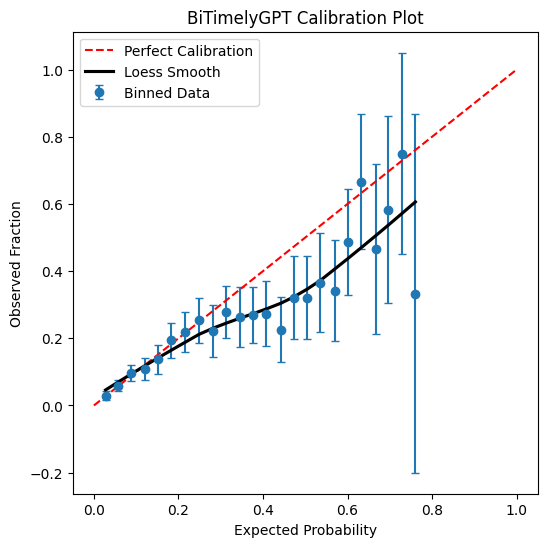

In [ ]:

########################################
# 3) Calibration Plot on set-c
########################################
import pandas as pd
import seaborn as sns

num_cuts = 24
df = pd.DataFrame({"prob": all_probs_test, "label": all_labels_test})

# 1) Bin predictions
df["bin"] = pd.cut(df["prob"], bins=num_cuts, include_lowest=True)

# 2) Group by bin, compute observed fraction, expected fraction, sample size, standard error
grouped = (
    df.groupby("bin")
    .agg(
        observed=("label", "mean"),
        expected=("prob", "mean"),
        n=("label", "count")
    )
    .reset_index()
)

grouped["se"] = np.sqrt(grouped["observed"] * (1 - grouped["observed"]) / grouped["n"])

# 3) Plot observed vs. expected
plt.figure(figsize=(6, 6))
plt.errorbar(
    x=grouped["expected"],
    y=grouped["observed"],
    yerr=1.96 * grouped["se"],
    fmt="o",
    capsize=3,
    label="Binned Data"
)
plt.plot([0, 1], [0, 1], "r--", label="Perfect Calibration")
sns.regplot(
    x="expected",
    y="observed",
    data=grouped,
    scatter=False,
    lowess=True,
    label="Loess Smooth",
    color="black"
)

plt.xlabel("Expected Probability")
plt.ylabel("Observed Fraction")
plt.title("BiTimelyGPT Calibration Plot")
plt.legend(loc="best")
plt.show()


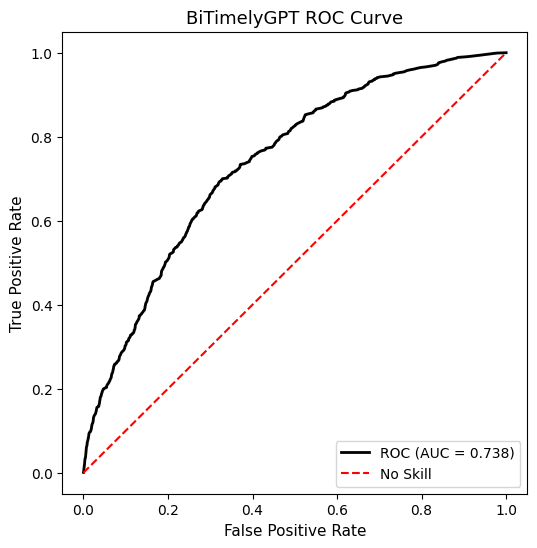

In [ ]:

########################################
# 4) ROC Curve on set-c
########################################
fpr_test, tpr_test, _ = roc_curve(all_labels_test, all_probs_test)
roc_auc_test = auc(fpr_test, tpr_test)

plt.figure(figsize=(6, 6))
sns.lineplot(x=fpr_test, y=tpr_test, color='black', linewidth=2,
             label=f'ROC (AUC = {roc_auc_test:.3f})')
plt.plot([0, 1], [0, 1], 'r--', label='No Skill')
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.title('BiTimelyGPT ROC Curve', fontsize=13)
plt.legend(loc='lower right')
plt.show()